In [12]:
import os
import polars as pl
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

COMBINED_ROOT = "/scratch/combined_datasets"
H5AD_ROOT = "/scratch/h5ad_outputs"


# Load cells by clusters

In [13]:
def get_leaf_type_df(
    table: str,
    filter_value: str,
    filter_col: str = "project_id",
    id_col: str | None = None,
    label_col: str | None = None,
    cluster_project_id: str | None = None,
    cast_id_to_int: bool = True,
) -> pd.DataFrame:
    """
    Load cell-to-type assignments from 'clustermembership' or 'celltoclustermapping',
    join the cluster hierarchy to find each cell's leaf-level (deepest) assignment,
    and return a tidy DataFrame with columns: id, predicted_label.

    Parameters
    ----------
    table : str
        Table name: 'clustermembership' or 'celltoclustermapping'.
    filter_value : str
        Value to filter on (e.g. project_id or mapping_set).
    filter_col : str
        Column to filter on (default 'project_id').
    id_col : str, optional
        Cell ID column. Auto-detected: 'item' for clustermembership, 'source_cell' otherwise.
    label_col : str, optional
        Label column. Auto-detected: 'cluster' or 'target_cluster'.
    cluster_project_id : str, optional
        Restrict cluster hierarchy lookup to this project_id.  Needed when a mapping
        table contains entries for multiple taxonomies (e.g. patchseq has both
        visp_met_types and tasic_2018_visp_scrnaseq clusters).
    cast_id_to_int : bool
        Cast the id column to int64 (default True).
        Set False for WNM-style compound string IDs.

    Returns
    -------
    pd.DataFrame with columns ['id', 'predicted_label'],
    one row per cell at its deepest assigned type.
    """
    if id_col is None:
        id_col = "item" if table == "clustermembership" else "source_cell"
    if label_col is None:
        label_col = "cluster" if table == "clustermembership" else "target_cluster"

    df = (
        pl.read_delta(os.path.join(COMBINED_ROOT, table))
        .filter(pl.col(filter_col) == filter_value)
        .select([id_col, label_col])
    )

    df_clusters = pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    if cluster_project_id:
        df_clusters = df_clusters.filter(pl.col("project_id") == cluster_project_id)

    result = (
        df
        .join(df_clusters.select(["id", "level"]), left_on=label_col, right_on="id", how="left")
        .sort("level", descending=True, nulls_last=True)
        .group_by(id_col)
        .first()
        .select([id_col, label_col])
        .rename({id_col: "id", label_col: "predicted_label"})
        .to_pandas()
    )

    if cast_id_to_int:
        result["id"] = result["id"].astype("int64")
    return result


In [14]:
# Minnie65 cell types from native ClusterMembership (CSM hierarchical subtype)
# Each cell appears once per hierarchy level; keep the deepest (leaf) assignment.
minnie_csm_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="minnie65",
    filter_col="project_id",
)
print(f"Minnie CSM: {len(minnie_csm_df)} cells, {minnie_csm_df['predicted_label'].nunique()} types")
print(minnie_csm_df['predicted_label'].value_counts())
minnie_csm_df.head()


Minnie CSM: 35780 cells, 13 types
predicted_label
L4IT    7348
L6CT    7245
L2IT    5038
L3IT    4444
L5IT    3327
L6IT    2895
PTC     1587
DTC     1466
L5ET     865
ITC      662
STC      460
L5NP     267
L6SP     176
Name: count, dtype: int64


,id,predicted_label
0,265055,L4IT
1,488637,DTC
2,290780,L2IT
3,396528,L4IT
4,222584,L2IT


In [15]:
# Minnie EXC MET types — umap+knn label transfer from patchseq
adata_exc = ad.read_h5ad(os.path.join(H5AD_ROOT, "exc_minnie_met_umapknn.h5ad"))
minnie_met_exc_df = adata_exc.obs[["id", "predicted_label"]].copy()
minnie_met_exc_df["id"] = minnie_met_exc_df["id"].astype("int64")

# Minnie INH MET types — umap+knn label transfer from patchseq
adata_inh = ad.read_h5ad(os.path.join(H5AD_ROOT, "inh_minnie_met_umapknn.h5ad"))
minnie_met_inh_df = adata_inh.obs[["id", "predicted_label"]].copy()
minnie_met_inh_df["id"] = minnie_met_inh_df["id"].astype("int64")

print(f"Minnie MET EXC: {len(minnie_met_exc_df)} cells, {minnie_met_exc_df['predicted_label'].nunique()} types")
print(f"Minnie MET INH: {len(minnie_met_inh_df)} cells, {minnie_met_inh_df['predicted_label'].nunique()} types")
minnie_met_exc_df.head()


Minnie MET EXC: 49714 cells, 17 types
Minnie MET INH: 163 cells, 19 types


,id,predicted_label
0,23141,L6b
1,23332,L6 IT-1
2,23373,L5 IT-2
3,23382,L6 IT-1
4,23385,L5 IT-2


In [16]:
# Patchseq MET types (EXC + INH) — ClusterMembership to visp_met_types taxonomy
# ClusterMembership for patchseq spans two taxonomies (visp_met_types + tasic_2018);
# restrict the cluster hierarchy join to visp_met_types so only MET-type leaf
# assignments (level=2) are returned.
patchseq_met_exc_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="visp_exc_patchseq",
    filter_col="project_id",
    cluster_project_id="visp_met_types",
)
patchseq_met_inh_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="visp_inh_patchseq",
    filter_col="project_id",
    cluster_project_id="visp_met_types",
)
print(f"Patchseq EXC MET: {len(patchseq_met_exc_df)} cells, {patchseq_met_exc_df['predicted_label'].nunique()} types")
print(f"Patchseq INH MET: {len(patchseq_met_inh_df)} cells, {patchseq_met_inh_df['predicted_label'].nunique()} types")
patchseq_met_exc_df.head()


Patchseq EXC MET: 384 cells, 17 types
Patchseq INH MET: 495 cells, 28 types


,id,predicted_label
0,904690163,L6 CT-2
1,644953476,L6 CT-1
2,966819173,L5 IT-3 Pld5
3,935214823,L6 CT-1
4,989164849,L5/L6 IT Car3


In [17]:
# Patchseq T-types (Tasic 2018) — CellToClusterMapping for EXC and INH
# Tasic hierarchy: level 0 (cell) → 1 (class) → 2 (subclass) → 3 (cluster = T-type leaf)
patchseq_ttype_exc_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_exc_patchseq_ttype_mapping",
    filter_col="mapping_set",
    cluster_project_id="tasic_2018_visp_scrnaseq",
)
patchseq_ttype_inh_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_inh_patchseq_ttype_mapping",
    filter_col="mapping_set",
    cluster_project_id="tasic_2018_visp_scrnaseq",
)
print(f"Patchseq EXC T-types: {len(patchseq_ttype_exc_df)} cells, {patchseq_ttype_exc_df['predicted_label'].nunique()} types")
print(f"Patchseq INH T-types: {len(patchseq_ttype_inh_df)} cells, {patchseq_ttype_inh_df['predicted_label'].nunique()} types")
patchseq_ttype_exc_df.head()


Patchseq EXC T-types: 1528 cells, 31 types
Patchseq INH T-types: 2759 cells, 54 types


,id,predicted_label
0,935795108,L6 IT VISp Penk Fst
1,907087713,L5 PT VISp C1ql2 Ptgfr
2,978149378,L5 PT VISp Krt80
3,947975387,L5 IT VISp Hsd11b1 Endou
4,963225872,L4 IT VISp Rspo1


In [18]:
# WNM MET types — CellToClusterMapping to visp_met_types taxonomy
# NOTE: WNM cell IDs are compound strings (e.g. '182709_6984-X2452-Y12423_reg')
# and cannot be cast to int. cast_id_to_int=False keeps them as strings.
wnm_met_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_exc_wnm_mettype_mapping",
    filter_col="mapping_set",
    cluster_project_id="visp_met_types",
    cast_id_to_int=False,
)
print(f"WNM MET: {len(wnm_met_df)} cells, {wnm_met_df['predicted_label'].nunique()} types")
print(wnm_met_df['predicted_label'].value_counts())
wnm_met_df.head()


WNM MET: 341 cells, 15 types
predicted_label
L2/3 IT           57
L5 ET-1 Chrna6    56
L5 ET-3           47
L4/L5 IT          41
L5 ET-2           40
L6 CT-2           23
L4 IT             20
L6b               17
L6 CT-1           16
L5/L6 IT Car3     10
L5 IT-2            8
L5 NP              3
L6 IT-1            1
L6 IT-2            1
L6 IT-3            1
Name: count, dtype: int64


,id,predicted_label
0,182725_7762-X3772-Y19585_reg,L5 ET-1 Chrna6
1,194069_7724-X4289-Y23661_reg,L5 ET-3
2,192343_5742-X3633-Y12817_reg,L2/3 IT
3,196476_8116-X4425-Y9934_reg,L6 CT-1
4,191807_7249-X4135-Y19813_reg,L5 ET-2


# Load cells x features

## Feature schemas

Read feature definitions (metadata about each feature column) and cell × feature matrices
for all datasets from the combined delta lake.

| Variable | Source | Contents |
|---|---|---|
| `featdef_csm_df` | `cellfeaturedefinition` (top-level) | 87 CSM + UMAP + coordinate feature definitions |
| `featdef_visp_exc_df` | `cellfeaturedefinition/visp_exc` | 50 patchseq EXC morph feature definitions |
| `featdef_visp_inh_df` | `cellfeaturedefinition/visp_inh` | 46 patchseq INH morph feature definitions |
| `featdef_minnie_exc_skel_df` | `cellfeaturedefinition/minnie_exc_skel_keys` | 55 Minnie EXC skeleton-key feature definitions |
| `featdef_minnie_inh_skel_df` | `cellfeaturedefinition/minnie_inh_skel_keys` | 51 Minnie INH skeleton-key feature definitions |
| `feats_csm_df` | `cellfeatures/csm_cluster_features` | 35,787 cells × 82 CSM morpho features |
| `feats_csm_umap_df` | `cellfeatures/csm_cluster_features_umap` | 35,787 cells × 2 UMAP coords |
| `feats_minnie_coords_df` | `cellfeatures/minnie65_std_transform_coordinates` | 133,969 cells × 3 soma coordinates |
| `feats_minnie_exc_skel_df` | `cellfeatures/minnie_exc_skel_keys` | 49,714 EXC cells × 55 skel-key features |
| `feats_minnie_inh_skel_df` | `cellfeatures/minnie_inh_skel_keys` | 163 INH cells × 51 skel-key features |
| `feats_patchseq_exc_df` | `cellfeatures/exc_morph_features` | 734 patchseq EXC cells × 50 morph features |
| `feats_patchseq_inh_df` | `cellfeatures/inh_morph_features` | 520 patchseq INH cells × 46 morph features |


In [19]:
# Feature definitions — metadata about each feature column

# Top-level: CSM cluster features, UMAP, and soma coordinates (all Minnie/Microns)
featdef_csm_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition')).to_pandas()

# VISp patchseq morph features (EXC and INH)
featdef_visp_exc_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'visp_exc')).to_pandas()
featdef_visp_inh_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'visp_inh')).to_pandas()

# Minnie skeleton-key morph features (EXC and INH)
featdef_minnie_exc_skel_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'minnie_exc_skel_keys')).to_pandas()
featdef_minnie_inh_skel_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'minnie_inh_skel_keys')).to_pandas()

print(f'CSM feature definitions:          {len(featdef_csm_df):>4d}  features')
print(f'VISp EXC morph definitions:       {len(featdef_visp_exc_df):>4d}  features')
print(f'VISp INH morph definitions:       {len(featdef_visp_inh_df):>4d}  features')
print(f'Minnie EXC skel-key definitions:  {len(featdef_minnie_exc_skel_df):>4d}  features')
print(f'Minnie INH skel-key definitions:  {len(featdef_minnie_inh_skel_df):>4d}  features')
featdef_csm_df.head()


CSM feature definitions:            87  features
VISp EXC morph definitions:         50  features
VISp INH morph definitions:         46  features
Minnie EXC skel-key definitions:    55  features
Minnie INH skel-key definitions:    51  features


,id,description,unit,data_type,range_min,range_max
0,x_umap,"umap low dimensional embedding feature, x coor...",ARBITRARY_UNIT,<f4,NaN,NaN
1,y_umap,"umap low dimensional embedding feature, y coor...",ARBITRARY_UNIT,<f4,NaN,NaN
2,nucleus_volume_um,Nucleus volume,MICRONS_CUBED,<f4,0.0,NaN
3,nucleus_area_um,Nucleus surface area,MICRONS_SQUARE,<f4,0.0,NaN
4,nuclear_area_to_volume_ratio,Nucleus surface area to volume ratio,MICRONS_INVERSE,<f4,0.0,NaN


In [20]:
# Cell x feature matrices — one row per cell, feature columns + id
# id is cast to int64 for all-numeric datasets; WNM cells keep string IDs.

def read_feats(sub_path: str, id_is_int: bool = True,
               project_id_filter: str | None = None) -> pd.DataFrame:
    """Read a cellfeatures delta table.
    Optionally filter to a specific project_id and cast id to int64.
    """
    df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeatures', sub_path))
    if project_id_filter is not None:
        df = df.filter(pl.col('project_id') == project_id_filter)
    result = df.to_pandas()
    if id_is_int:
        result['id'] = result['id'].astype('int64')
    return result

# Minnie CSM features (synapse-centric morphology used for CSM clustering)
feats_csm_df              = read_feats('csm_cluster_features')

# Minnie CSM UMAP embedding coordinates
feats_csm_umap_df         = read_feats('csm_cluster_features_umap')

# Minnie soma coordinates (standard-transform: y=0 at pia surface)
feats_minnie_coords_df    = read_feats('minnie65_std_transform_coordinates')

# Minnie skeleton-key morph features (comparable feature space to VISp morph)
feats_minnie_exc_skel_df  = read_feats('minnie_exc_skel_keys')
feats_minnie_inh_skel_df  = read_feats('minnie_inh_skel_keys')

# VISp patchseq morph features
# exc_morph_features contains both patchseq and WNM cells; split by project_id.
# WNM IDs are compound strings, patchseq IDs are numeric.
feats_patchseq_exc_df     = read_feats('exc_morph_features',
                                        project_id_filter='visp_exc_patchseq')
feats_wnm_exc_df          = read_feats('exc_morph_features', id_is_int=False,
                                        project_id_filter='visp_exc_wnm')
feats_patchseq_inh_df     = read_feats('inh_morph_features')

print(f'feats_csm_df:              {feats_csm_df.shape[0]:>7,} cells x {feats_csm_df.shape[1]-1:>3} features')
print(f'feats_csm_umap_df:         {feats_csm_umap_df.shape[0]:>7,} cells x {feats_csm_umap_df.shape[1]-1:>3} features')
print(f'feats_minnie_coords_df:    {feats_minnie_coords_df.shape[0]:>7,} cells x {feats_minnie_coords_df.shape[1]-1:>3} features')
print(f'feats_minnie_exc_skel_df:  {feats_minnie_exc_skel_df.shape[0]:>7,} cells x {feats_minnie_exc_skel_df.shape[1]-1:>3} features')
print(f'feats_minnie_inh_skel_df:  {feats_minnie_inh_skel_df.shape[0]:>7,} cells x {feats_minnie_inh_skel_df.shape[1]-1:>3} features')
print(f'feats_patchseq_exc_df:     {feats_patchseq_exc_df.shape[0]:>7,} cells x {feats_patchseq_exc_df.shape[1]-1:>3} features')
print(f'feats_wnm_exc_df:          {feats_wnm_exc_df.shape[0]:>7,} cells x {feats_wnm_exc_df.shape[1]-1:>3} features')
print(f'feats_patchseq_inh_df:     {feats_patchseq_inh_df.shape[0]:>7,} cells x {feats_patchseq_inh_df.shape[1]-1:>3} features')
feats_csm_df.head()


feats_csm_df:               35,787 cells x  84 features
feats_csm_umap_df:          35,787 cells x   4 features
feats_minnie_coords_df:    133,969 cells x   5 features
feats_minnie_exc_skel_df:   49,714 cells x  57 features
feats_minnie_inh_skel_df:      163 cells x  53 features
feats_patchseq_exc_df:         389 cells x  52 features
feats_wnm_exc_df:              345 cells x  52 features
feats_patchseq_inh_df:         520 cells x  48 features


,id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,...,branch_svd0,branch_svd1,branch_svd2,branch_svd3,branch_svd4,ego_count_pca0,ego_count_pca1,ego_count_pca2,project_id,feature_set_id
0,485509,344.116638,269.338379,0.782695,4873741.0,0.017687,0.309179,1112.999878,1202.533447,537.425110,...,62.978085,0.950874,0.729539,-1.328438,4.192588,1.960875,0.805681,-0.739578,minnie65,csm_cluster_features
1,263203,254.538391,250.433167,0.983872,30756560.0,0.123807,0.397382,640.537720,934.029358,361.333221,...,31.198191,-4.262416,0.754856,1.729803,1.534398,0.588246,-0.777625,-0.096427,minnie65,csm_cluster_features
2,456177,338.026459,298.603607,0.883373,35204028.0,0.124294,0.366174,923.129578,1017.687988,365.622009,...,56.717365,4.266992,9.265330,-0.329062,7.591257,-0.729798,-0.946995,0.546816,minnie65,csm_cluster_features
3,461339,328.602386,300.213623,0.913608,38599868.0,0.126401,0.324381,1013.014954,1051.013306,1082.797363,...,34.661217,0.517283,3.532224,3.231579,-0.251822,0.552461,-0.534918,-0.287912,minnie65,csm_cluster_features
4,302377,292.694000,327.721680,1.119673,67134240.0,0.197033,0.349798,836.752563,1107.547852,977.260864,...,45.571911,-3.164315,4.887801,2.438147,0.188189,-0.621269,-0.941240,-0.753779,minnie65,csm_cluster_features


# Load Connectome (cell-to-cell connectivity schema)

In [21]:
# Cell-cell connectivity (long format)
conn_df = pl.read_delta(os.path.join(COMBINED_ROOT, "cellcellconnectivitylong"))
print(f"Connectivity: {conn_df.height:,} rows")
print("measurement_type values:", conn_df["measurement_type"].unique().to_list())

Connectivity: 1,592,196 rows
measurement_type values: ['SYNAPSE_COUNT', 'SUM_ANATOMICAL_SIZE']


---

# Visualisation

In [41]:
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np


def stretch_to_match(
    df_source: pd.DataFrame,
    df_target: pd.DataFrame,
    group_col: str,
) -> pd.DataFrame:
    """Resample *df_source* rows within each group to match *df_target* group counts.

    For each unique value of *group_col* in *df_target*, the corresponding rows in
    *df_source* are resampled (nearest-neighbour via np.linspace) to produce exactly
    as many rows as *df_target* has for that group.  Groups absent from *df_source*
    are silently skipped.  The returned DataFrame has the same group order as
    *df_target*.
    """
    parts = []
    seen: set = set()
    ordered_groups = [g for g in df_target[group_col]
                      if g not in seen and not seen.add(g)]  # type: ignore[func-returns-value]
    for group in ordered_groups:
        n_target = int((df_target[group_col] == group).sum())
        src_rows = df_source[df_source[group_col] == group]
        m = len(src_rows)
        if m == 0:
            continue
        idx = np.round(np.linspace(0, m - 1, n_target)).astype(int)
        parts.append(src_rows.iloc[idx].reset_index(drop=True))
    return pd.concat(parts, ignore_index=True)


def merge_strips(id_col: str, *specs) -> pd.DataFrame:
    """Inner-join several DataFrames on *id_col*, keeping only cells present in all.

    Each spec is one of:
        (df, [col1, col2, ...])                 – keep listed columns + id_col
        (df, [col1, ...], {'old': 'new', ...})  – also rename columns after selection

    Returns a single merged DataFrame.
    """
    result = None
    for spec in specs:
        df_in, cols = spec[0], spec[1]
        rename = spec[2] if len(spec) > 2 else {}
        keep = list({id_col} | set(cols))
        df_sel = df_in[keep].rename(columns=rename)
        result = df_sel if result is None else result.merge(df_sel, on=id_col, how="inner")
    return result.reset_index(drop=True)


def plot_strips(
    df: pd.DataFrame,
    features: list[dict] | None = None,
    labels: list[dict] | None = None,
    sort_by: list[str] | None = None,
    colorbar_position: str = "top",   # 'top' | 'bottom'
    average_by=None,  # str | list[str] | None — group cols for feature averaging
    fig=None,  # optional existing Figure or SubFigure
    strips: list[dict] | None = None,  # ordered mixed list; each dict has type="feature"|"label"
) -> plt.Figure:
    """Plot a sorted cell-strip figure.

    Parameters
    ----------
    df : pd.DataFrame
        One row per cell.  Must contain all columns referenced by *features* and *labels*.
    features : list of dict, optional
        Each dict: {'col': str, 'title': str, 'cmap': str}.
        Features appear left-to-right in list order.  Pass [] or None for no feature str ip.
    labels : list of dict, optional
        Each dict: {'col': str, 'title': str, 'colors': dict[str, str]}.
        Strips appear left-to-right after features.  A legend is added for each.
    sort_by : list of str, optional
        Column names (in *df*) to sort rows by, in priority order.  Independent of
        which columns are displayed.
    colorbar_position : 'top' | 'bottom'
        Where to place feature colorbars.  Ignored when *features* is empty.
    fig : matplotlib.figure.Figure or SubFigure, optional
        Existing figure to draw into.  When None (default) a new figure is
        created.  Pass a SubFigure to embed strips inside a larger layout.
    average_by : str or list of str, optional
        Column(s) to group by when averaging feature values.  Every cell in the
        same group receives the group mean as its feature value.  Label strips are
        unaffected.  Feature strip titles get an " (avg)" suffix.
    strips : list of dict, optional
        Ordered mixed list of strip descriptors.  Each dict must have a
        ``type`` key set to ``"feature"``, ``"label"``, or ``"heatmap"``,
        plus the fields that would appear in *features* or *labels*
        respectively.  When provided, *strips* takes precedence over
        *features* and *labels*, enabling arbitrary interleaving.
        Heatmap dict: {type, cols, title, cmap}.  *cols* is a list of
        column names in *df* that form the 2-D connectivity matrix.  A
        single shared colorbar is drawn; ``average_by`` averages each
        column identically to regular features.

    Returns
    -------
    matplotlib.figure.Figure
    """
    # When strips= is provided, derive features and labels from it (preserving order).
    if strips is not None:
        features = [dict({k: v for k, v in s.items() if k != "type"}) for s in strips if s.get("type") == "feature"]
        labels   = [dict({k: v for k, v in s.items() if k != "type"}) for s in strips if s.get("type") == "label"]
        strip_order = strips  # remember the interleaved order
    else:
        strip_order = None
    features = features or []
    labels   = labels   or []
    sort_by  = sort_by  or []

    # Heatmaps: extract column lists for average_by processing
    heatmap_strips = [s for s in (strip_order or []) if s.get("type") == "heatmap"]

    # Normalize average_by and compute group means for feature columns + heatmap cols
    if average_by is not None and isinstance(average_by, str):
        average_by = [average_by]
    if average_by is not None:
        feat_cols = [f["col"] for f in features]
        hm_cols   = [c for s in heatmap_strips for c in s.get("cols", [])]
        all_avg_cols = feat_cols + hm_cols
        if all_avg_cols:
            df = df.copy()
            df[all_avg_cols] = df.groupby(average_by)[all_avg_cols].transform("mean")

    # Sort rows
    if sort_by:
        df = df.sort_values(sort_by).reset_index(drop=True)
    n_cells = len(df)

    n_feats  = len(features)
    n_labels = len(labels)

    has_cb   = n_feats > 0
    n_rows   = 2 if has_cb else 1
    if has_cb:
        cb_row    = 0 if colorbar_position == "top" else 1
        strip_row = 1 if colorbar_position == "top" else 0
    else:
        cb_row    = None  # unused
        strip_row = 0

    # Column widths: feature strips wider, label strips narrow, legend axes
    FEAT_W   = 1.5
    LABEL_W  = 0.5
    LEG_W    = 2.2
    n_heatmaps = len([s for s in (strip_order or []) if s.get("type") == "heatmap"])
    n_strips = n_feats + n_labels + n_heatmaps
    n_cols = n_strips + n_labels  # strips | legends (heatmaps have no legend)

    HEATMAP_COL_W = 0.015  # width units per postsynaptic column in heatmap
    HEATMAP_MAX_W = 8.0    # cap total heatmap width
    if strip_order is not None:
        # Mixed ordering: assign column index according to strips list
        def _strip_width(s):
            if s["type"] == "heatmap":
                return min(HEATMAP_MAX_W, max(FEAT_W, len(s.get("cols", [])) * HEATMAP_COL_W))
            return FEAT_W if s["type"] == "feature" else LABEL_W
        strip_widths = [_strip_width(s) for s in strip_order]
    else:
        strip_widths = [FEAT_W] * n_feats + [LABEL_W] * n_labels
    width_ratios = strip_widths + [LEG_W] * n_labels

    # Figure width; minimum 2 inches if only labels and legends
    total_w = max(2.5, sum(width_ratios))
    fig_h = 8.0

    if n_rows == 2:
        height_ratios = ([0.06, 0.94] if colorbar_position == "top"
                         else [0.94, 0.06])
    else:
        height_ratios = [1]

    if fig is None:
        fig = plt.figure(figsize=(total_w, fig_h), layout="constrained")
    gs = fig.add_gridspec(
        n_rows, n_cols,
        height_ratios=height_ratios,
        width_ratios=width_ratios,
        wspace=0.04,
        hspace=0.04,
    )

    # ── Build ordered strip list (feature, label, or heatmap) ───────────────
    if strip_order is not None:
        ordered_strips = strip_order
    else:
        ordered_strips = ([dict(s, type="feature") for s in features]
                          + [dict(s, type="label") for s in labels])

    # Counters to look up per-type im handles for colorbars
    feat_ims: list = []  # (col_idx, im) pairs for individual feature strips
    hm_ims:   list = []  # (col_idx, im) pairs for heatmap strips (shared cb)

    for col_idx, strip in enumerate(ordered_strips):
        stype = strip["type"]
        if stype == "feature":
            vals = df[strip["col"]].values.reshape(-1, 1).astype(float)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            im = ax_strip.imshow(
                vals, aspect="auto", cmap=strip.get("cmap", "viridis"),
                vmin=np.nanmin(vals), vmax=np.nanmax(vals),
                interpolation="nearest",
            )
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            _title = strip.get("title", strip["col"])
            if average_by is not None:
                _title += " (avg)"
            ax_strip.set_title(_title, fontsize=8, pad=3)
            feat_ims.append((col_idx, im))
        elif stype == "heatmap":
            cols = strip.get("cols", [])
            mat = df[cols].values.astype(float)  # shape: (n_cells, n_post)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            _vmin_hm = strip.get("vmin", None)
            _vmax_hm = strip.get("vmax", None)
            im = ax_strip.imshow(
                mat, aspect="auto", cmap=strip.get("cmap", "viridis"),
                vmin=_vmin_hm, vmax=_vmax_hm,
                interpolation="nearest",
            )
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            _title = strip.get("title", "Connectivity")
            if average_by is not None:
                _title += " (avg)"
            ax_strip.set_title(_title, fontsize=8, pad=3)
            hm_ims.append((col_idx, im))
        else:  # label
            rgba_arr = np.array([
                mcolors.to_rgba(strip["colors"].get(v, "#cccccc"))
                for v in df[strip["col"]]
            ]).reshape(-1, 1, 4)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            ax_strip.imshow(rgba_arr, aspect="auto", interpolation="nearest")
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            ax_strip.set_title(strip.get("title", strip["col"]), fontsize=8, pad=3)

    # ── Colorbars ────────────────────────────────────────────────────────────
    if has_cb:
        # Individual feature colorbars
        for col_idx, im in feat_ims:
            ax_cb = fig.add_subplot(gs[cb_row, col_idx])
            fig.colorbar(im, cax=ax_cb, orientation="horizontal")
            ax_cb.tick_params(labelsize=6)
            if colorbar_position == "bottom":
                ax_cb.xaxis.tick_bottom()
                ax_cb.xaxis.set_label_position("bottom")
        # Shared colorbar for heatmap strips (use first heatmap's image handle,
        # but normalise all heatmap images to the global min/max first)
        if hm_ims:
            # Use explicit vmin/vmax from first heatmap strip if provided;
            # otherwise fall back to the global data min/max.
            first_hm_strip = next(s for s in (strip_order or []) if s.get("type") == "heatmap")
            if first_hm_strip.get("vmin") is not None or first_hm_strip.get("vmax") is not None:
                all_hm_vals = np.concatenate([
                    im.get_array().ravel()  # type: ignore[union-attr]
                    for _, im in hm_ims
                ])
                vmin_hm = first_hm_strip.get("vmin", float(np.nanmin(all_hm_vals)))
                vmax_hm = first_hm_strip.get("vmax", float(np.nanmax(all_hm_vals)))
            else:
                all_hm_vals = np.concatenate([
                    im.get_array().ravel()  # type: ignore[union-attr]
                    for _, im in hm_ims
                ])
                vmin_hm, vmax_hm = np.nanmin(all_hm_vals), np.nanmax(all_hm_vals)
            for _, im in hm_ims:
                im.set_clim(vmin_hm, vmax_hm)
            # Draw a single shared colorbar anchored to the first heatmap strip
            first_hm_col, first_hm_im = hm_ims[0]
            ax_cb_hm = fig.add_subplot(gs[cb_row, first_hm_col])
            cb_hm = fig.colorbar(first_hm_im, cax=ax_cb_hm, orientation="horizontal")
            cb_hm.ax.tick_params(labelsize=6)
            if colorbar_position == "bottom":
                ax_cb_hm.xaxis.tick_bottom()
                ax_cb_hm.xaxis.set_label_position("bottom")
            # Spacer axes for remaining heatmap colorbar slots
            for col_idx, _ in hm_ims[1:]:
                ax_sp = fig.add_subplot(gs[cb_row, col_idx])
                ax_sp.axis("off")
        # Spacer axes for label/other strips in colorbar row
        for col_idx, strip in enumerate(ordered_strips):
            if strip["type"] not in ("feature", "heatmap"):
                ax_empty = fig.add_subplot(gs[cb_row, col_idx])
                ax_empty.axis("off")

    # ── Legend axes (one per label, span all rows; heatmaps have no legend) ─
    for k, lbl in enumerate(labels):
        col_idx = n_strips + k
        ax_leg = fig.add_subplot(gs[:, col_idx])
        present = sorted(df[lbl["col"]].unique())
        patches = [
            mpatches.Patch(color=lbl["colors"].get(v, "#cccccc"), label=v)
            for v in present
        ]
        ncol = 2 if len(present) > 20 else 1
        ax_leg.legend(
            handles=patches,
            title=lbl.get("title", lbl["col"]),
            fontsize=7, title_fontsize=8,
            loc="upper left", frameon=False,
            ncol=ncol, handlelength=1.1, handletextpad=0.5, columnspacing=0.8,
        )
        ax_leg.axis("off")

    return fig

def conn_to_feature_table(
    conn_df,
    measurement_type: str = "SYNAPSE_COUNT",
    agg: str = "sum",
    rows: str = "post",
    pre_ids=None,
    post_ids=None,
    fill_value: float = 0.0,
) -> tuple[pd.DataFrame, list[str]]:
    """Reshape long-format cell-cell connectivity into a feature matrix.

    Parameters
    ----------
    conn_df : polars.DataFrame
        Long-format table with columns: presynaptic_cell, postsynaptic_cell,
        value, measurement_type.
    measurement_type : str
        Filter to this measurement type (e.g. "SYNAPSE_COUNT").
    agg : "sum" | "mean"
        How to aggregate value within each (pre, post) pair.
    rows : "post" | "pre"
        Orientation of the output matrix.
        "post" (default) → rows = postsynaptic cells, columns = pre_<id>
        "pre"            → rows = presynaptic  cells, columns = post_<id>
    pre_ids, post_ids : list-like, optional
        Restrict presynaptic / postsynaptic cells to this set.
    fill_value : float
        Value for missing (pre, post) pairs (default 0.0).

    Returns
    -------
    df : pd.DataFrame
        Wide DataFrame with an "id" column (row-cell IDs) and one column
        per opposite-side cell named "pre_<id>" or "post_<id>".
    feat_cols : list[str]
        Ordered list of the feature column names, ready for a heatmap strip.
    """
    df = conn_df.filter(pl.col("measurement_type") == measurement_type)

    def _cast(ids, col):
        dtype = df.schema[col]
        if dtype in (pl.Utf8, pl.String):
            return [str(x) for x in ids]
        elif dtype in (pl.Int64, pl.Int32, pl.Int16, pl.Int8):
            return [int(x) for x in ids]
        return list(ids)

    if pre_ids is not None:
        df = df.filter(pl.col("presynaptic_cell").is_in(_cast(pre_ids, "presynaptic_cell")))
    if post_ids is not None:
        df = df.filter(pl.col("postsynaptic_cell").is_in(_cast(post_ids, "postsynaptic_cell")))

    if agg == "sum":
        agg_expr = pl.col("value").sum()
    elif agg == "mean":
        agg_expr = pl.col("value").mean()
    else:
        raise ValueError(f"agg must be 'sum' or 'mean'; got {agg!r}")

    df_agg = (
        df.group_by(["presynaptic_cell", "postsynaptic_cell"])
        .agg(agg_expr.alias("value"))
    )

    if rows == "post":
        row_col, pivot_col, prefix = "postsynaptic_cell", "presynaptic_cell", "pre"
    else:
        row_col, pivot_col, prefix = "presynaptic_cell", "postsynaptic_cell", "post"

    df_wide = df_agg.pivot(
        on=pivot_col,
        index=row_col,
        values="value",
        aggregate_function=None,
    ).fill_null(fill_value)

    pdf = df_wide.to_pandas()
    feat_id_cols = sorted(
        [c for c in pdf.columns if c != row_col],
        key=lambda x: str(x).lstrip("-").zfill(20),
    )
    rename_map = {c: f"{prefix}_{c}" for c in feat_id_cols}
    pdf = pdf.rename(columns={row_col: "id", **rename_map})
    feat_cols = [f"{prefix}_{c}" for c in feat_id_cols]
    pdf[feat_cols] = pdf[feat_cols].astype("float64").fillna(fill_value)
    return pdf, feat_cols


def plot_conn_heatmap(
    mat,
    row_annotations=None,
    col_annotations=None,
    vmin=None,
    vmax=None,
    cmap="binary",
    title="",
    show_colorbar=False,
):
    """Connectivity heatmap with horizontal column annotations (top) and
    vertical row annotations (right).

    Parameters
    ----------
    mat : np.ndarray, shape (n_rows, n_cols)
        Connectivity matrix, already sorted.
    row_annotations : list of dict, optional
        Each dict: {type: "label"|"feature", title, values (1-D array aligned
        to rows), colors (for label) or cmap (for feature)}.
        Rendered as narrow vertical strips to the right of the heatmap.
    col_annotations : list of dict, optional
        Each dict: {type: "label", title, values (1-D array aligned to cols),
        colors}.
        Rendered as thin horizontal strips above the heatmap.
    vmin, vmax : float, optional
        Color scale limits for the heatmap.
    cmap : str
        Colormap for the heatmap.
    title : str
        Title placed above the heatmap.
    show_colorbar : bool
        Whether to draw a colorbar.  Default False.
    """
    row_annotations = row_annotations or []
    col_annotations = col_annotations or []

    n_col_strips  = len(col_annotations)
    n_row_strips  = len(row_annotations)
    # Label annotations that need their own legend column
    col_labels = [a for a in col_annotations if a.get("type") == "label"]
    row_labels = [a for a in row_annotations if a.get("type") == "label"]
    n_legends  = len(col_labels) + len(row_labels)

    # ── Figure geometry ───────────────────────────────────────────────────
    HM_H        = 7.0   # heatmap height (inches)
    HM_W        = 8.0   # heatmap width  (inches)
    COL_STRIP_H = 0.15  # height of each column-annotation strip
    ROW_STRIP_W = 0.35  # width  of each row-annotation strip
    CB_W        = 0.25  # colorbar width
    CB_PAD      = 0.20
    LEG_W       = 2.2   # width of each legend column

    gs_nrows = n_col_strips + 1
    gs_ncols = (1
                + n_row_strips
                + (1 if show_colorbar else 0)
                + n_legends)

    h_ratios = [COL_STRIP_H] * n_col_strips + [HM_H]
    w_ratios = ([HM_W]
                + [ROW_STRIP_W] * n_row_strips
                + ([CB_W + CB_PAD] if show_colorbar else [])
                + [LEG_W] * n_legends)

    fig = plt.figure(figsize=(sum(w_ratios), sum(h_ratios)), layout="constrained")
    gs = fig.add_gridspec(
        gs_nrows, gs_ncols,
        height_ratios=h_ratios,
        width_ratios=w_ratios,
        hspace=0.02,
        wspace=0.02,
    )

    hm_row = n_col_strips

    # ── Column annotation strips ──────────────────────────────────────────
    for k, ann in enumerate(col_annotations):
        ax = fig.add_subplot(gs[k, 0])
        rgba = np.array(
            [mcolors.to_rgba(ann["colors"].get(v, "#cccccc")) for v in ann["values"]]
        ).reshape(1, -1, 4)
        ax.imshow(rgba, aspect="auto", interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([0])
        ax.set_yticklabels([ann.get("title", "")], fontsize=7)
        ax.tick_params(left=False, length=0)

    # ── Main heatmap ──────────────────────────────────────────────────────
    ax_hm = fig.add_subplot(gs[hm_row, 0])
    im = ax_hm.imshow(
        mat, aspect="auto", cmap=cmap,
        vmin=vmin, vmax=vmax, interpolation="nearest",
    )
    ax_hm.set_xticks([])
    ax_hm.set_yticks([])
    if title:
        ax_hm.set_title(title, fontsize=9)

    # ── Row annotation strips ─────────────────────────────────────────────
    for k, ann in enumerate(row_annotations):
        ax = fig.add_subplot(gs[hm_row, 1 + k])
        if ann.get("type") == "label":
            rgba = np.array(
                [mcolors.to_rgba(ann["colors"].get(v, "#cccccc")) for v in ann["values"]]
            ).reshape(-1, 1, 4)
            ax.imshow(rgba, aspect="auto", interpolation="nearest")
        else:
            vals = np.array(ann["values"]).reshape(-1, 1).astype(float)
            ax.imshow(vals, aspect="auto",
                      cmap=ann.get("cmap", "viridis"), interpolation="nearest")
        ax.set_yticks([])
        ax.set_xticks([0])
        ax.set_xticklabels([ann.get("title", "")], fontsize=7, rotation=90)
        ax.tick_params(bottom=False, length=0)
        for r in range(n_col_strips):
            fig.add_subplot(gs[r, 1 + k]).axis("off")

    # ── Colorbar ──────────────────────────────────────────────────────────
    cb_col = 1 + n_row_strips
    if show_colorbar:
        ax_cb = fig.add_subplot(gs[hm_row, cb_col])
        fig.colorbar(im, cax=ax_cb)
        ax_cb.tick_params(labelsize=7)
        for r in range(n_col_strips):
            fig.add_subplot(gs[r, cb_col]).axis("off")

    # ── Legends: one column per label annotation, col labels first ────────
    # Col-annotation legends span only the heatmap row (can't span col strips
    # meaningfully); row-annotation legends span full height.
    leg_start_col = cb_col + (1 if show_colorbar else 0)
    for i, ann in enumerate(col_labels + row_labels):
        leg_col = leg_start_col + i
        ax_leg = fig.add_subplot(gs[hm_row, leg_col])
        present = sorted(set(ann["values"]))
        patches = [
            mpatches.Patch(color=ann["colors"].get(v, "#cccccc"), label=v)
            for v in present
        ]
        ncol = 2 if len(present) > 20 else 1
        ax_leg.legend(
            handles=patches,
            title=ann.get("title", ""),
            fontsize=6, title_fontsize=7,
            loc="upper left", frameon=False,
            ncol=ncol,
            handlelength=1.0, handletextpad=0.4, columnspacing=0.7,
        )
        ax_leg.axis("off")
        for r in range(n_col_strips):
            fig.add_subplot(gs[r, leg_col]).axis("off")

    return fig


In [33]:
# ── Standard colour dictionaries ──────────────────────────────────────────────
# These can be reused across all demo calls.

# MET types: hex_color from visp_met_types taxonomy (level=2 = leaf clusters)
df_met_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "visp_met_types") & (pl.col("level") == 2))
    .select(["id", "hex_color"])
)
met_colors = dict(zip(df_met_clusters["id"].to_list(),
                      df_met_clusters["hex_color"].to_list()))

# CSM types: hex_color from minnie65 cluster schema (level=2 = leaf subtypes)
df_csm_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "minnie65") & (pl.col("level") == 2))
    .select(["id", "hex_color"])
)
csm_colors = dict(zip(df_csm_clusters["id"].to_list(),
                      df_csm_clusters["hex_color"].to_list()))

# Build Tasic T-type colour dict from cluster taxonomy
df_tasic_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "tasic_2018_visp_scrnaseq") & (pl.col("level") == 3))
    .select(["id", "hex_color"])
)
ttype_colors = dict(zip(df_tasic_clusters["id"].to_list(),
                        df_tasic_clusters["hex_color"].to_list()))

print(f"met_colors: {len(met_colors)} types")
print(f"csm_colors: {len(csm_colors)} types")
print(f"ttype_colors: {len(ttype_colors)} types")


met_colors: 45 types
csm_colors: 13 types
ttype_colors: 111 types


# Cell to Cell connectivity schema to be transformed to cell by features
where each row is a presynaptic cell with known types, each column/feature is a postsynaptic id and the "aggregate" is user selected like number of synapses or total size of synapses.

then visualize this like in # Demo 1 cell. but instead of a strip, it will be a heatmap.

pay attention to alignment with csm and whatnot types

- requires a third mode where strips are one shared colorbar)
    - mode 1: feature: strip - colorbar
    - mode 2: label: strip - category legend
    - mode 3: heatmap: feature strips - shared one colorbar

## Rows are presynaptic cells

Presynaptic  (≥0 sent):     1,962
Postsynaptic (≥0 received): 63,221
Feature matrix: 1,962 presynaptic rows × 63221 postsynaptic columns
Columns after CSM filter: 34,722 postsynaptic cells
Row cells after label join: 1,582 presynaptic cells


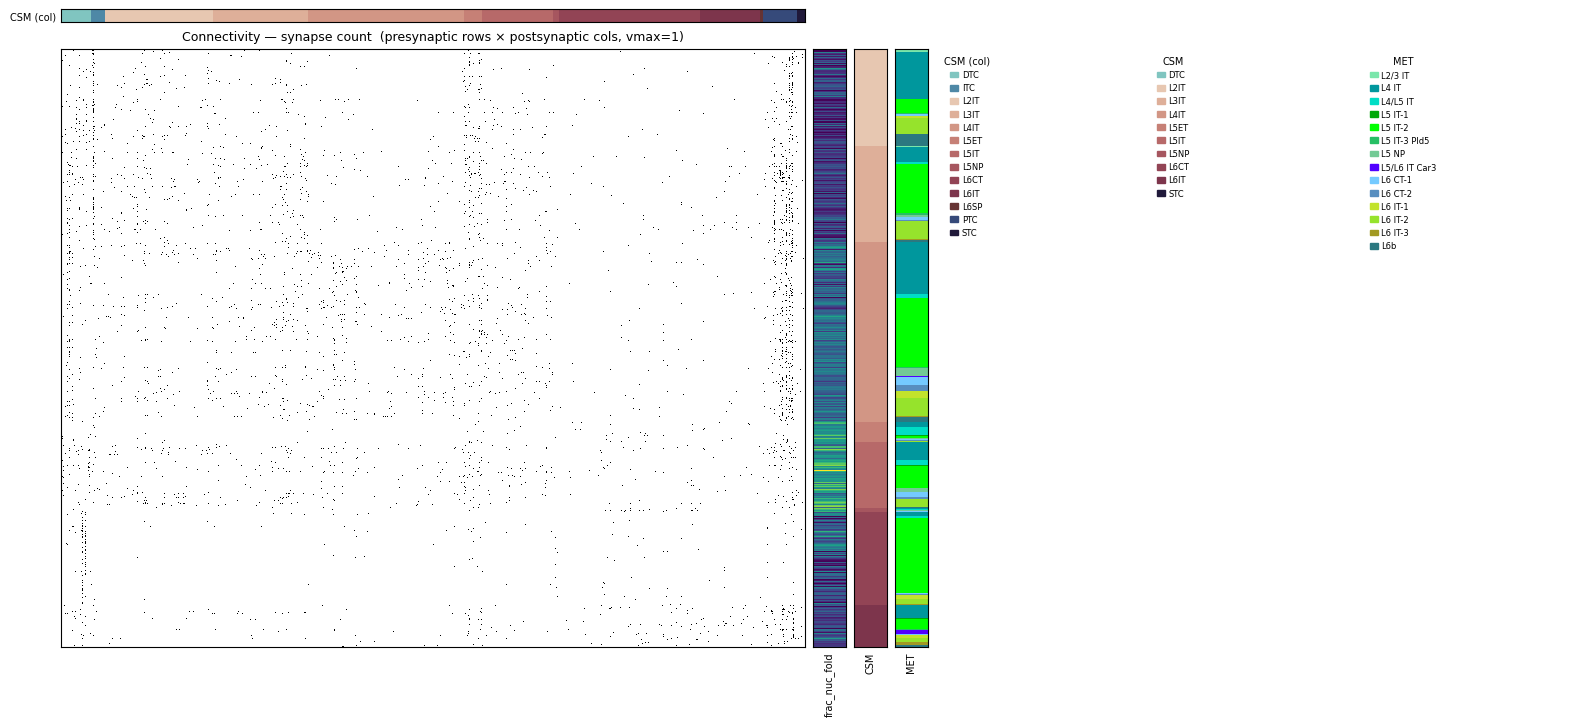

In [42]:
# Demo conn 2: plain imshow heatmap + horizontal column annotations (top)
#              + vertical row annotations (right)
# Columns filtered to cells that have CSM labels.
# No averaging.

ROWS    = "pre"   # "pre" → rows=presynaptic, cols=postsynaptic
MIN_SYN = 0      # minimum total synapses to include a cell on either side
VMAX    = 1       # colorbar saturation

_row_side = "presynaptic"  if ROWS == "pre" else "postsynaptic"
_col_side = "postsynaptic" if ROWS == "pre" else "presynaptic"

# ── Filter both sides by minimum total synapse count ──────────────────────
syn_count = conn_df.filter(pl.col("measurement_type") == "SYNAPSE_COUNT")

pre_totals  = syn_count.group_by("presynaptic_cell").agg(pl.col("value").sum().alias("total"))
post_totals = syn_count.group_by("postsynaptic_cell").agg(pl.col("value").sum().alias("total"))

pre_ids_conn  = pre_totals.filter(pl.col("total")  >= MIN_SYN)["presynaptic_cell"].to_list()
post_ids_conn = post_totals.filter(pl.col("total") >= MIN_SYN)["postsynaptic_cell"].to_list()
print(f"Presynaptic  (≥{MIN_SYN} sent):     {len(pre_ids_conn):,}")
print(f"Postsynaptic (≥{MIN_SYN} received): {len(post_ids_conn):,}")

# ── Build feature matrix ───────────────────────────────────────────────────
conn_feat_df, feat_cols = conn_to_feature_table(
    conn_df,
    measurement_type="SYNAPSE_COUNT",
    agg="sum",
    rows=ROWS,
    pre_ids=pre_ids_conn,
    post_ids=post_ids_conn,
    fill_value=0.0,
)
print(f"Feature matrix: {conn_feat_df.shape[0]:,} {_row_side} rows × {len(feat_cols)} {_col_side} columns")

# ── Build column annotation DataFrame ─────────────────────────────────────
# Extract cell IDs from column names (e.g. "post_123456" → 123456)
_col_prefix = feat_cols[0].split("_")[0] + "_"  # "post_" or "pre_"
col_ids = [int(c[len(_col_prefix):]) for c in feat_cols]

col_annot_df = pd.DataFrame({"id": col_ids, "feat_col": feat_cols})
# Filter columns to those with CSM labels
col_annot_df = col_annot_df.merge(
    minnie_csm_df[["id", "predicted_label"]].rename(columns={"predicted_label": "csm_label"}),
    on="id", how="inner",
)
# Optionally add MET label for columns (inner join keeps only cells with both)
# col_annot_df = col_annot_df.merge(
#     minnie_met_exc_df[["id","predicted_label"]].rename(columns={"predicted_label":"met_label"}),
#     on="id", how="inner",
# )
col_annot_df = col_annot_df.sort_values("csm_label").reset_index(drop=True)
feat_cols_filtered = col_annot_df["feat_col"].tolist()
print(f"Columns after CSM filter: {len(feat_cols_filtered):,} {_col_side} cells")

# ── Merge row cells with scalar feature + label columns ───────────────────
df_rows = conn_feat_df[["id"] + feat_cols_filtered].copy()
df_rows["id"] = df_rows["id"].astype("int64")

df_rows = merge_strips("id",
    (df_rows, feat_cols_filtered),
    (feats_csm_df, ["fraction_nuclear_folding"]),
    (minnie_csm_df, ["predicted_label"], {"predicted_label": "csm_label"}),
    (minnie_met_exc_df, ["predicted_label"], {"predicted_label": "met_label"}),
)
df_rows = df_rows.sort_values(["csm_label", "met_label"]).reset_index(drop=True)
print(f"Row cells after label join: {len(df_rows):,} {_row_side} cells")

# ── Extract sorted matrix ─────────────────────────────────────────────────
mat = df_rows[feat_cols_filtered].values.astype(float)

# ── Plot ───────────────────────────────────────────────────────────────────
fig = plot_conn_heatmap(
    mat,
    col_annotations=[
        {
            "type": "label",
            "title": "CSM (col)",
            "values": col_annot_df["csm_label"].tolist(),
            "colors": csm_colors,
        },
    ],
    row_annotations=[
        {
            "type": "feature",
            "title": "frac_nuc_fold",
            "values": df_rows["fraction_nuclear_folding"].tolist(),
            "cmap": "viridis",
        },
        {
            "type": "label",
            "title": "CSM",
            "values": df_rows["csm_label"].tolist(),
            "colors": csm_colors,
        },
        {
            "type": "label",
            "title": "MET",
            "values": df_rows["met_label"].tolist(),
            "colors": met_colors,
        },
    ],
    vmin=0,
    vmax=VMAX,
    cmap="binary",
    title=f"Connectivity — synapse count  ({_row_side} rows × {_col_side} cols, vmax={VMAX})",
)
plt.show()


## rows are postsynaptic cells

Presynaptic  (≥0 sent):     1,962
Postsynaptic (≥0 received): 63,221
Feature matrix: 63,221 postsynaptic rows × 1962 presynaptic columns
Columns after CSM filter: 1,861 presynaptic cells
Row cells after label join: 28,646 postsynaptic cells


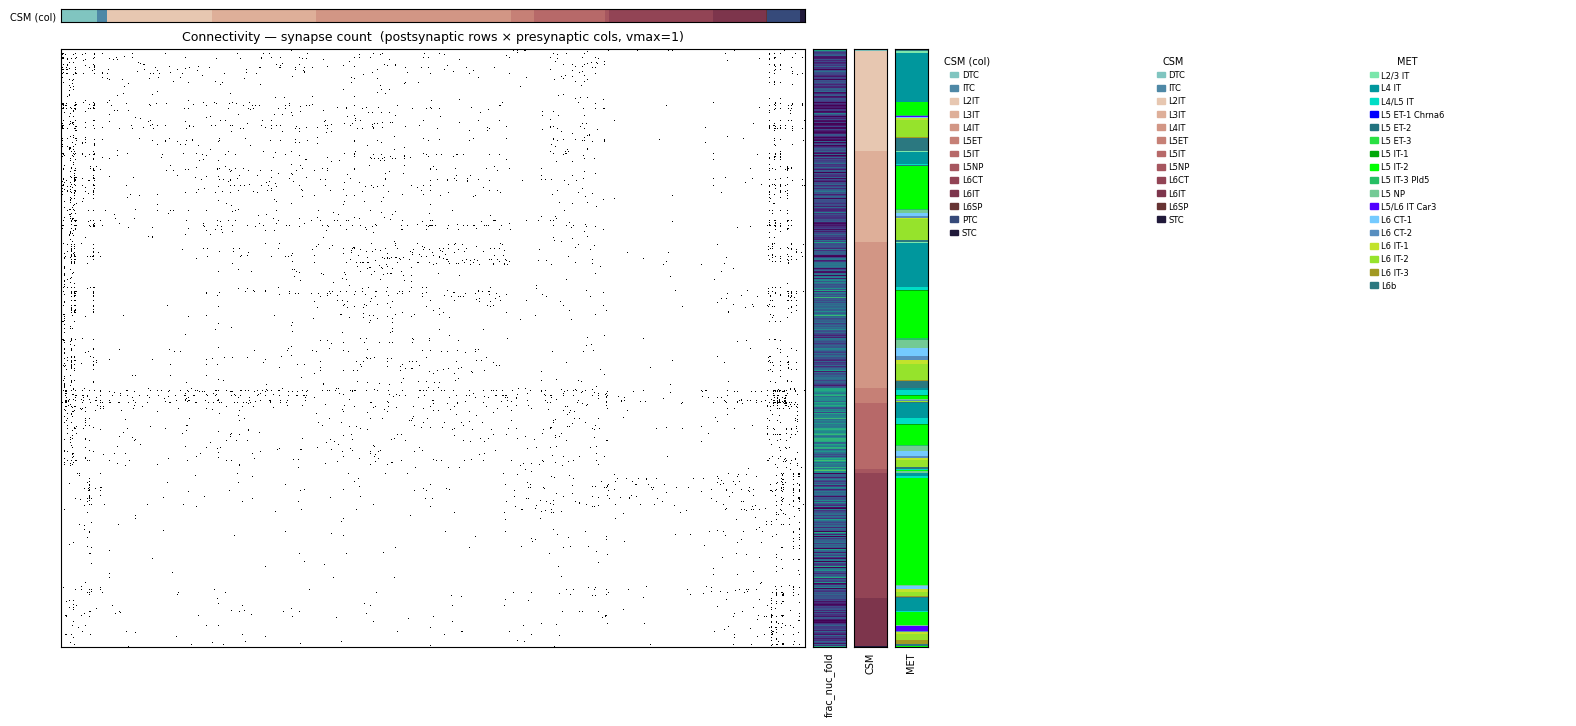

In [43]:
# Demo conn 2: plain imshow heatmap + horizontal column annotations (top)
#              + vertical row annotations (right)
# Columns filtered to cells that have CSM labels.
# No averaging.

ROWS    = "post"   # "pre" → rows=presynaptic, cols=postsynaptic
MIN_SYN = 0      # minimum total synapses to include a cell on either side

_row_side = "presynaptic"  if ROWS == "pre" else "postsynaptic"
_col_side = "postsynaptic" if ROWS == "pre" else "presynaptic"

# ── Filter both sides by minimum total synapse count ──────────────────────
syn_count = conn_df.filter(pl.col("measurement_type") == "SYNAPSE_COUNT")

pre_totals  = syn_count.group_by("presynaptic_cell").agg(pl.col("value").sum().alias("total"))
post_totals = syn_count.group_by("postsynaptic_cell").agg(pl.col("value").sum().alias("total"))

pre_ids_conn  = pre_totals.filter(pl.col("total")  >= MIN_SYN)["presynaptic_cell"].to_list()
post_ids_conn = post_totals.filter(pl.col("total") >= MIN_SYN)["postsynaptic_cell"].to_list()
print(f"Presynaptic  (≥{MIN_SYN} sent):     {len(pre_ids_conn):,}")
print(f"Postsynaptic (≥{MIN_SYN} received): {len(post_ids_conn):,}")

# ── Build feature matrix ───────────────────────────────────────────────────
conn_feat_df, feat_cols = conn_to_feature_table(
    conn_df,
    measurement_type="SYNAPSE_COUNT",
    agg="sum",
    rows=ROWS,
    pre_ids=pre_ids_conn,
    post_ids=post_ids_conn,
    fill_value=0.0,
)
print(f"Feature matrix: {conn_feat_df.shape[0]:,} {_row_side} rows × {len(feat_cols)} {_col_side} columns")

# ── Build column annotation DataFrame ─────────────────────────────────────
# Extract cell IDs from column names (e.g. "post_123456" → 123456)
_col_prefix = feat_cols[0].split("_")[0] + "_"  # "post_" or "pre_"
col_ids = [int(c[len(_col_prefix):]) for c in feat_cols]

col_annot_df = pd.DataFrame({"id": col_ids, "feat_col": feat_cols})
# Filter columns to those with CSM labels
col_annot_df = col_annot_df.merge(
    minnie_csm_df[["id", "predicted_label"]].rename(columns={"predicted_label": "csm_label"}),
    on="id", how="inner",
)
# Optionally add MET label for columns (inner join keeps only cells with both)
# col_annot_df = col_annot_df.merge(
#     minnie_met_exc_df[["id","predicted_label"]].rename(columns={"predicted_label":"met_label"}),
#     on="id", how="inner",
# )
col_annot_df = col_annot_df.sort_values("csm_label").reset_index(drop=True)
feat_cols_filtered = col_annot_df["feat_col"].tolist()
print(f"Columns after CSM filter: {len(feat_cols_filtered):,} {_col_side} cells")

# ── Merge row cells with scalar feature + label columns ───────────────────
df_rows = conn_feat_df[["id"] + feat_cols_filtered].copy()
df_rows["id"] = df_rows["id"].astype("int64")

df_rows = merge_strips("id",
    (df_rows, feat_cols_filtered),
    (feats_csm_df, ["fraction_nuclear_folding"]),
    (minnie_csm_df, ["predicted_label"], {"predicted_label": "csm_label"}),
    (minnie_met_exc_df, ["predicted_label"], {"predicted_label": "met_label"}),
)
df_rows = df_rows.sort_values(["csm_label", "met_label"]).reset_index(drop=True)
print(f"Row cells after label join: {len(df_rows):,} {_row_side} cells")

# ── Extract sorted matrix ─────────────────────────────────────────────────
mat = df_rows[feat_cols_filtered].values.astype(float)

# ── Plot ───────────────────────────────────────────────────────────────────
VMAX=1
fig = plot_conn_heatmap(
    mat,
    col_annotations=[
        {
            "type": "label",
            "title": "CSM (col)",
            "values": col_annot_df["csm_label"].tolist(),
            "colors": csm_colors,
        },
    ],
    row_annotations=[
        {
            "type": "feature",
            "title": "frac_nuc_fold",
            "values": df_rows["fraction_nuclear_folding"].tolist(),
            "cmap": "viridis",
        },
        {
            "type": "label",
            "title": "CSM",
            "values": df_rows["csm_label"].tolist(),
            "colors": csm_colors,
        },
        {
            "type": "label",
            "title": "MET",
            "values": df_rows["met_label"].tolist(),
            "colors": met_colors,
        },
    ],
    vmin=0,
    vmax=VMAX,
    cmap="binary",
    title=f"Connectivity — synapse count  ({_row_side} rows × {_col_side} cols, vmax={VMAX})",
)
plt.show()